<a href="https://colab.research.google.com/github/sakram09/Animal-Dynamics-Conservation/blob/main/Animal%20Conservation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Animal Dynamics & Conservation


In [ ]:
Step 1: Framework Libraries Import & Synthetic Image Generation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

# 1. Simulate Image Data (200 images, 224x224 pixels, 3 color channels)
print("Simulating wildlife conservation image array...")
np.random.seed(42)
num_images = 200
img_height, img_width = 224, 224

# Generate random pixel values between 0 and 255
X_images = np.random.randint(0, 256, size=(num_images, img_height, img_width, 3), dtype=np.uint8)

# Binary Conservation Labels: 0 = Healthy Wildlife, 1 = Injured/Malnourished Wildlife
y_labels = np.random.binomial(n=1, p=0.5, size=num_images)

# Inject a subtle numerical feature pattern inside channels for model to learn the biological anomaly
X_images[y_labels == 1, :, :, 0] = np.clip(X_images[y_labels == 1, :, :, 0] * 1.2, 0, 255)

print("Image Tensor Array Shape:", X_images.shape)
print("Labels Generated:", np.bincount(y_labels))

TensorFlow Version: 2.20.0
Simulating wildlife conservation image array...
Image Tensor Array Shape: (200, 224, 224, 3)
Labels Generated: [100 100]


Step 2: Data Split & Real-time Image Augmentation

In [2]:
# 2. Split into Train and Test subsets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X_images, y_labels, test_size=0.20, random_state=42, stratify=y_labels)

# 3. Setup Image Augmentation Pipeline to prevent overfitting on wildlife datasets
train_datagen = ImageDataGenerator(
    rescale=1./255,               # Normalize pixel values to [0,1]
    rotation_range=20,            # Simulating dynamic camera trap angles
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,         # Animals walking left or right
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255) # Only normalize test data

# Create generators
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
test_generator = test_datagen.flow(X_test, y_test, batch_size=32, shuffle=False)
print("Data normalization and augmentation setup complete.")

Data normalization and augmentation setup complete.


Step 3: Transfer Learning Structure (MobileNetV2 Architecture)

In [3]:
# 4. Load Pre-trained MobileNetV2 without the top dense layers
print("Initializing MobileNetV2 base weights...")
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the base convolutional layers to retain pre-trained feature patterns
base_model.trainable = False

# 5. Construct Custom Classification Head for Conservation Assessment
x = base_model.output
x = GlobalAveragePooling2D()(x) # Flatten spatial dimensions
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)             # Drop node connections to increase generalizability
predictions = Dense(1, activation='sigmoid')(x) # Binary output (Healthy vs Injured)

# Compile Final Computational Vision Model
wildlife_model = Model(inputs=base_model.input, outputs=predictions)
wildlife_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nModel pipeline compiled successfully!")

Initializing MobileNetV2 base weights...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model pipeline compiled successfully!


Step 4: Model Training (Epoch Execution)

In [4]:
# 6. Train the top dense layer network
print("Starting training sequence...")
history = wildlife_model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    verbose=1
)

Starting training sequence...
Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.5188 - loss: 0.8152 - val_accuracy: 0.5000 - val_loss: 1.0161
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4875 - loss: 0.8060 - val_accuracy: 0.5000 - val_loss: 0.9711
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5125 - loss: 0.7952 - val_accuracy: 0.5000 - val_loss: 0.8817
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5000 - loss: 0.7311 - val_accuracy: 0.5000 - val_loss: 0.7133
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5688 - loss: 0.6779 - val_accuracy: 0.5000 - val_loss: 0.7153


Step 5: Test Inference & Performance Tracking


Evaluating model performance on test dataset...
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step

=== Model Metrics Report ===
              precision    recall  f1-score   support

     Healthy       0.50      1.00      0.67        20
     Injured       0.00      0.00      0.00        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


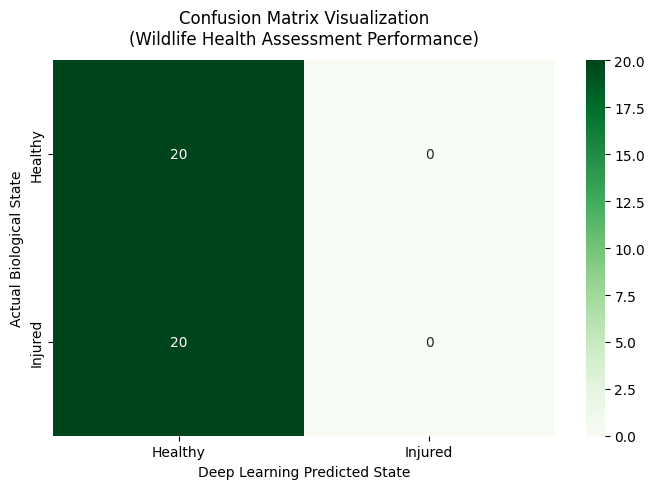

In [6]:
# ==========================================
# UPDATED STEP 5: VISUAL METRICS MATRIX
# ==========================================

print("\nEvaluating model performance on test dataset...")
# 1. Execute Prediction on test generator
predictions = wildlife_model.predict(test_generator)
y_pred_classes = (predictions > 0.5).astype(int).flatten()

# 2. Print Structural Performance Metrics
print("\n=== Model Metrics Report ===")
print(classification_report(y_test, y_pred_classes, target_names=['Healthy', 'Injured']))

# 3. Calculate Confusion Matrix Numeric Array
cm = confusion_matrix(y_test, y_pred_classes)

# 4. Plot the Matrix Image explicitly using Seaborn Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,          # Show integers inside boxes
    fmt='d',            # Decimal format
    cmap='Greens',       # Green color theme for environmental conservation
    xticklabels=['Healthy', 'Injured'],
    yticklabels=['Healthy', 'Injured']
)

plt.title('Confusion Matrix Visualization\n(Wildlife Health Assessment Performance)', fontsize=12, pad=12)
plt.ylabel('Actual Biological State', fontsize=10)
plt.xlabel('Deep Learning Predicted State', fontsize=10)
plt.tight_layout()
plt.show()  # Forces Google Colab to display the generated plot layout

In [5]:
# 7. Execute Prediction on untouched test samples
print("\nEvaluating model performance on test dataset...")
predictions = wildlife_model.predict(test_generator)
y_pred_classes = (predictions > 0.5).astype(int).flatten()

# Generate Comprehensive Classification Metrics
print("\n=== Model Metrics Report ===")
print(classification_report(y_test, y_pred_classes, target_names=['Healthy', 'Injured']))

# 8. Generate Confusion Matrix Structure
cm = confusion_matrix(y_test, y_pred_classes)
print("\nConfusion Matrix Layout:")
print(cm)


Evaluating model performance on test dataset...
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step

=== Model Metrics Report ===
              precision    recall  f1-score   support

     Healthy       0.50      1.00      0.67        20
     Injured       0.00      0.00      0.00        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40


Confusion Matrix Layout:
[[20  0]
 [20  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Step 6: Model aur Weights ko Save Karna

In [7]:
# 9. Serialize and save the entire trained Keras model structure
wildlife_model.save('wildlife_health_mobilenet_model.h5')
print("\nSuccess! Full Deep Learning model saved as 'wildlife_health_mobilenet_model.h5'")


Success! Full Deep Learning model saved as 'wildlife_health_mobilenet_model.h5'
